# AI for Radiologic Image Tasks - *Mastering Artificial Intelligence in Radiology*
## Classification

This notebook introduces a complete, educational workflow for training a binary chest X-ray classifier. The task is to predict whether an image belongs to the `No TB` class or the `TB` class.

The notebook uses the NLM Shenzhen ChinaSet as the training source. These images are split into a training group, used to update the model, and an internal validation group, used to monitor how well the model is learning. The Montgomery County dataset is kept separate and is only used at the end as an external validation set. This separation helps demonstrate the difference between checking performance on familiar data and checking performance on images from another dataset.

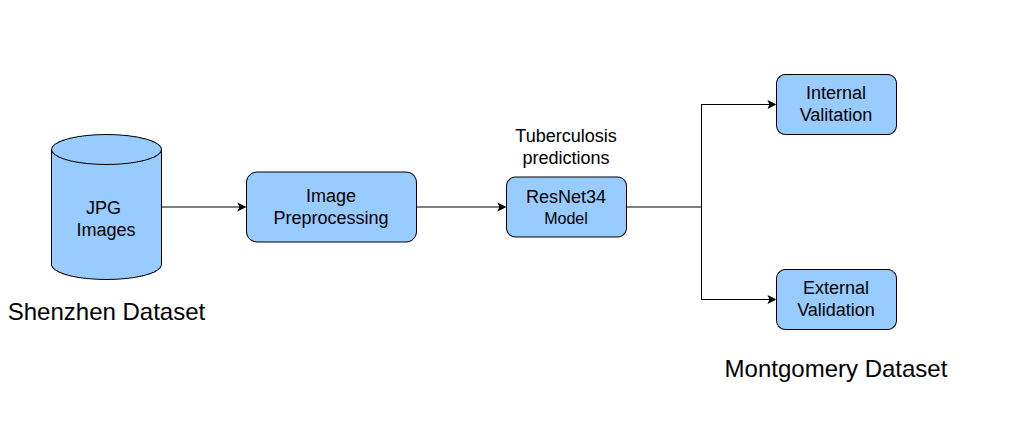

The main steps are:

1. Build an image index with file paths, labels, and readable class names.
2. Load and normalize chest X-ray images so they are in a consistent format.
3. Create a balanced train/validation split from the Shenzhen dataset.
4. Prepare PyTorch datasets and loaders, including simple image augmentation for training.
5. Define a small convolutional neural network for binary classification.
6. Train the model while tracking loss, accuracy, F1 score, and AUC.
7. Evaluate the trained model on both internal and external validation data.

The goal is not to build a production-ready medical AI system. Instead, the notebook is meant to make the main logic behind image classification clear: organize the data, prepare images, train a model, and evaluate whether its predictions generalize beyond the training dataset.




## 0. Setup

This section imports the libraries, fixes the random seed for repeatable results, defines the dataset folders, and selects the compute device.

Before running the notebook, replace the dataset directory paths in the code cell below with the locations where the Shenzhen and Montgomery datasets are stored on your own environment. The notebook expects each dataset directory to contain a `CXR_png` folder with the image files.



In [ ]:
from pathlib import Path
import random
import warnings

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import resnet34
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["image.cmap"] = "gray"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set these paths to the dataset locations on your own computer.
SHENZHEN_DATASET_DIR = Path("datasets/ChinaSet_AllFiles")
SHENZHEN_IMAGE_DIR = SHENZHEN_DATASET_DIR / "CXR_png"

MONTGOMERY_DATASET_DIR = Path("datasets/NLM-MontgomeryCXRSet/MontgomerySet")
MONTGOMERY_IMAGE_DIR = MONTGOMERY_DATASET_DIR / "CXR_png"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


assert SHENZHEN_IMAGE_DIR.exists(), f"Shenzhen image directory not found: {SHENZHEN_IMAGE_DIR}"
assert MONTGOMERY_IMAGE_DIR.exists(), f"Montgomery image directory not found: {MONTGOMERY_IMAGE_DIR}"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}; CUDA build: {torch.version.cuda}")
print(f"Training and internal validation images: {SHENZHEN_IMAGE_DIR}")
print(f"External validation images: {MONTGOMERY_IMAGE_DIR}")


## 1. Build Image Index

Here we create a simple table with one row per image. Each row stores the dataset name, image ID, file path, numeric label, and readable label name. This table becomes the source of truth for the rest of the notebook.



In [31]:
def disease_label_from_id(image_id: str) -> int:
    suffix = image_id.rsplit("_", 1)[-1]
    if suffix not in {"0", "1"}:
        raise ValueError(f"Expected image id to end with _0 or _1, got {image_id!r}")
    return int(suffix)


def build_tb_classification_index(dataset: str, image_dir: Path) -> pd.DataFrame:
    rows = []
    for image_path in sorted(image_dir.glob("*.png")):
        image_id = image_path.stem
        label = disease_label_from_id(image_id)
        rows.append({
            "Dataset": dataset,
            "ImageId": image_id,
            "image_path": image_path,
            "disease_label": label,
            "label_name": "TB" if label == 1 else "No TB",
        })
    return pd.DataFrame(rows)


images_df = build_tb_classification_index("Shenzhen", SHENZHEN_IMAGE_DIR)
external_images_df = build_tb_classification_index("Montgomery", MONTGOMERY_IMAGE_DIR)
assert not images_df.empty, "No Shenzhen PNG images found."
assert not external_images_df.empty, "No Montgomery PNG images found."

print(f"Images indexed from Shenzhen for training/internal validation: {len(images_df):,}")
print(f"Images indexed from Montgomery for external validation: {len(external_images_df):,}")

pd.concat([images_df, external_images_df], ignore_index=True).groupby(["Dataset", "label_name"]).size().rename("images").to_frame()

Images indexed from Shenzhen for training/internal validation: 662
Images indexed from Montgomery for external validation: 138


images
Dataset    label_name        
Montgomery No TB           80
           TB              58
Shenzhen   No TB          326
           TB             336

## 2. Image Loading And Label Check

This section loads a few images from the datasets and displays them with their labels. The image files are read from disk with OpenCV as grayscale images, which means each image becomes a two-dimensional array of pixel intensity values instead of a color image with red, green, and blue channels.

The notebook then applies a simple brightness normalization before plotting the samples. For now, the goal is simply to look at some examples before preparing the images for model training.



In [32]:
def read_grayscale_png(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return image


def normalize_percentile(image: np.ndarray, lower: float = 1, upper: float = 99, eps: float = 1e-7) -> np.ndarray:
    image = image.astype(np.float32)
    lo, hi = np.percentile(image, [lower, upper])
    image = np.clip(image, lo, hi)
    return ((image - lo) / (hi - lo + eps)).astype(np.float32)


def image_and_label(image_id: str, metadata: pd.DataFrame | None = None) -> tuple[np.ndarray, int]:
    metadata = images_df if metadata is None else metadata
    row = metadata.loc[metadata["ImageId"] == image_id].iloc[0]
    image = read_grayscale_png(row.image_path)
    label = int(row.disease_label)
    return image, label

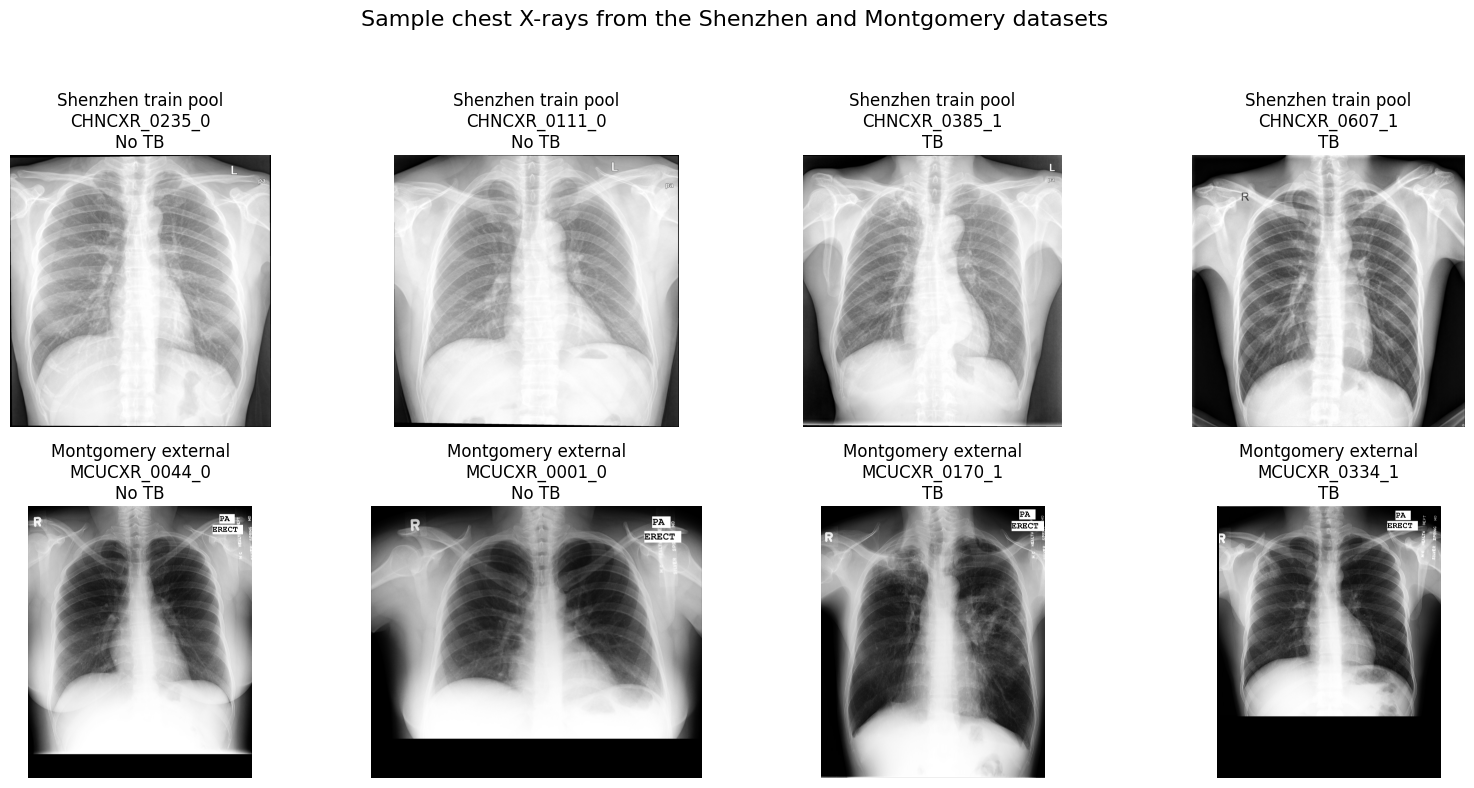

In [33]:
def sample_by_label(df: pd.DataFrame, n: int = 2) -> pd.DataFrame:
    return df.groupby("disease_label", group_keys=False).sample(n=n, random_state=SEED)


sample_rows = pd.concat([
    sample_by_label(images_df).assign(Split="Shenzhen train pool"),
    sample_by_label(external_images_df).assign(Split="Montgomery external"),
], ignore_index=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Sample chest X-rays from the Shenzhen and Montgomery datasets", fontsize=16)
axes = np.array(axes).reshape(-1)

for ax, row in zip(axes, sample_rows.itertuples(index=False)):
    image = normalize_percentile(read_grayscale_png(row.image_path))
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{row.Split}\n{row.ImageId}\n{row.label_name}")
    ax.axis("off")

for ax in axes[len(sample_rows):]:
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.94])


## 3. Shenzhen Train/Validation Split

The Shenzhen dataset is divided into two internal groups before training:

- **Training split:** 80% of the Shenzhen images, used to update the model weights.
- **Validation split:** 20% of the Shenzhen images, kept separate and used to monitor performance during training.

The split is **stratified by label**, meaning the notebook preserves a similar TB / No TB proportion in both groups. This matters because a random split could accidentally place more TB cases in one group and more No TB cases in the other, making validation metrics harder to interpret.

This validation split gives us an internal check: the model is evaluated on images it did not train on, but those images still come from the same Shenzhen source. This helps detect overfitting and guides checkpoint selection before we test the model on the separate Montgomery external dataset.



In [34]:
def stratified_image_split(df: pd.DataFrame, valid_fraction: float = 0.2, seed: int = SEED):
    rng = np.random.default_rng(seed)
    train_ids, valid_ids = [], []
    for _, group in df.groupby("disease_label"):
        ids = group["ImageId"].to_numpy().copy()
        rng.shuffle(ids)
        n_valid = max(1, int(round(len(ids) * valid_fraction)))
        valid_ids.extend(ids[:n_valid])
        train_ids.extend(ids[n_valid:])
    train_ids = np.array(train_ids)
    valid_ids = np.array(valid_ids)
    rng.shuffle(train_ids)
    rng.shuffle(valid_ids)
    return train_ids, valid_ids


train_ids, valid_ids = stratified_image_split(images_df)
external_ids = external_images_df["ImageId"].to_numpy()
label_lookup = images_df.set_index("ImageId")["disease_label"]
external_label_lookup = external_images_df.set_index("ImageId")["disease_label"]

pd.DataFrame({
    "split": ["shenzhen_all", "shenzhen_train", "shenzhen_valid", "montgomery_external"],
    "images": [len(images_df), len(train_ids), len(valid_ids), len(external_ids)],
    "tb_fraction": [
        images_df["disease_label"].mean(),
        label_lookup.loc[train_ids].mean(),
        label_lookup.loc[valid_ids].mean(),
        external_label_lookup.loc[external_ids].mean(),
    ],
})


,split,images,tb_fraction
0,shenzhen_all,662,0.507553
1,shenzhen_train,530,0.507547
2,shenzhen_valid,132,0.507576
3,montgomery_external,138,0.420290


## 4. PyTorch Classification Dataset

This section prepares images for the model by defining the transformations and the PyTorch dataset class.

Data augmentation means making small random changes to the training images each time they are loaded. The label stays the same, but the model sees slightly different versions of the same type of image. This helps the model learn patterns that are more general, instead of memorizing the exact position, size, or brightness of the training examples.

In this notebook, the training images use these augmentation techniques:

1. Resize: makes every image the same input size for the neural network.
2. Shift, scale, and rotation: slightly moves, zooms, or rotates the image.
3. Horizontal flip: mirrors the image left-to-right.
4. Brightness and contrast changes: slightly adjusts image appearance.

Validation and external validation images are not randomly augmented. They are only resized and normalized, so evaluation is consistent and easier to interpret.



In [35]:
def make_train_transform(size: int) -> A.Compose:
    return A.Compose([
        A.Resize(height=size, width=size),
        A.ShiftScaleRotate(
            shift_limit=0.03,
            scale_limit=0.08,
            rotate_limit=7,
            p=0.5,
            border_mode=cv2.BORDER_CONSTANT,
        ),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.08, contrast_limit=0.08, p=0.35),
    ])


def make_valid_transform(size: int) -> A.Compose:
    return A.Compose([
        A.Resize(height=size, width=size),
    ])


def compute_train_image_stats(
    image_ids,
    metadata: pd.DataFrame,
    transform: A.Compose | None = None,
    eps: float = 1e-7,
) -> tuple[np.ndarray, np.ndarray]:
    metadata = metadata.set_index("ImageId")
    pixel_sum = 0.0
    pixel_squared_sum = 0.0
    pixel_count = 0

    for image_id in tqdm(image_ids, desc="Calculating train mean/std", leave=False):
        row = metadata.loc[image_id]
        image = normalize_percentile(read_grayscale_png(row.image_path))
        if transform is not None:
            image = transform(image=image)["image"]
        image = image.astype(np.float64)

        pixel_sum += image.sum()
        pixel_squared_sum += np.square(image).sum()
        pixel_count += image.size

    mean = pixel_sum / max(1, pixel_count)
    variance = max(pixel_squared_sum / max(1, pixel_count) - mean**2, 0.0)
    std = max(float(np.sqrt(variance)), eps)
    return np.array([mean, mean, mean], dtype=np.float32), np.array([std, std, std], dtype=np.float32)


class TBClassificationDataset(Dataset):
    def __init__(
        self,
        image_ids,
        metadata: pd.DataFrame,
        transform: A.Compose | None = None,
        image_mean: np.ndarray | None = None,
        image_std: np.ndarray | None = None,
    ):
        self.image_ids = list(image_ids)
        self.metadata = metadata.set_index("ImageId")
        self.transform = transform
        if image_mean is None or image_std is None:
            raise ValueError("Pass train-set image_mean and image_std to normalize this dataset.")
        self.image_mean = np.asarray(image_mean, dtype=np.float32).reshape(1, 1, 3)
        self.image_std = np.asarray(image_std, dtype=np.float32).reshape(1, 1, 3)

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        row = self.metadata.loc[image_id]
        image = normalize_percentile(read_grayscale_png(row.image_path))
        label = np.array([row.disease_label], dtype=np.float32)

        if self.transform is not None:
            transformed = self.transform(image=image)
            image = transformed["image"].astype(np.float32)

        image = np.repeat(image[..., None], 3, axis=-1)
        image = (image - self.image_mean) / self.image_std
        image = np.ascontiguousarray(image.transpose(2, 0, 1))

        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label)
        return image, label, image_id

In the next cell, we use the dataset class defined above and choose the main data-loading settings for this project.

`IMAGE_SIZE` defines the standard image size used by the model. `BATCH_SIZE` controls how many images are processed at once. `NUM_WORKERS` controls how many background processes help load the images. The normalization statistics are calculated from the training images and then reused for training, internal validation, and external validation.

In [36]:
IMAGE_SIZE = 384
BATCH_SIZE = 16
NUM_WORKERS = 4

MAX_TRAIN_IMAGES = None
MAX_VALID_IMAGES = None
MAX_EXTERNAL_IMAGES = None

train_transform = make_train_transform(IMAGE_SIZE)
valid_transform = make_valid_transform(IMAGE_SIZE)

train_ids_run = train_ids[:MAX_TRAIN_IMAGES] if MAX_TRAIN_IMAGES else train_ids
valid_ids_run = valid_ids[:MAX_VALID_IMAGES] if MAX_VALID_IMAGES else valid_ids
external_ids_run = external_ids[:MAX_EXTERNAL_IMAGES] if MAX_EXTERNAL_IMAGES else external_ids

TRAIN_IMAGE_MEAN, TRAIN_IMAGE_STD = compute_train_image_stats(train_ids_run, images_df, transform=valid_transform)
print(f"Training image mean used for normalization: {TRAIN_IMAGE_MEAN}")
print(f"Training image standard deviation used for normalization: {TRAIN_IMAGE_STD}")

train_ds = TBClassificationDataset(
    train_ids_run,
    images_df,
    transform=train_transform,
    image_mean=TRAIN_IMAGE_MEAN,
    image_std=TRAIN_IMAGE_STD,
)
valid_ds = TBClassificationDataset(
    valid_ids_run,
    images_df,
    transform=valid_transform,
    image_mean=TRAIN_IMAGE_MEAN,
    image_std=TRAIN_IMAGE_STD,
)
external_valid_ds = TBClassificationDataset(
    external_ids_run,
    external_images_df,
    transform=valid_transform,
    image_mean=TRAIN_IMAGE_MEAN,
    image_std=TRAIN_IMAGE_STD,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
external_valid_loader = DataLoader(external_valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

images, labels, image_ids = next(iter(train_loader))

print(f"One training batch contains {images.shape[0]} images.")
print(f"Image tensor shape: {images.shape} = batch, channels, height, width")
print(f"Label tensor shape: {labels.shape} = one binary label per image")
print(f"Example image IDs from this batch: {list(image_ids[:2])}")
print(f"External validation images available: {len(external_valid_ds)}")


Training image mean used for normalization: [0.6539272 0.6539272 0.6539272]
Training image standard deviation used for normalization: [0.28502104 0.28502104 0.28502104]


One training batch contains 16 images.
Image tensor shape: torch.Size([16, 3, 384, 384]) = batch, channels, height, width
Label tensor shape: torch.Size([16, 1]) = one binary label per image
Example image IDs from this batch: [np.str_('CHNCXR_0238_0'), np.str_('CHNCXR_0170_0')]
External validation images available: 138


The next cell shows how data augmentation changes a training image. The first panel displays the resized image without random augmentation, and the other panels show different augmented versions created from the same original image.

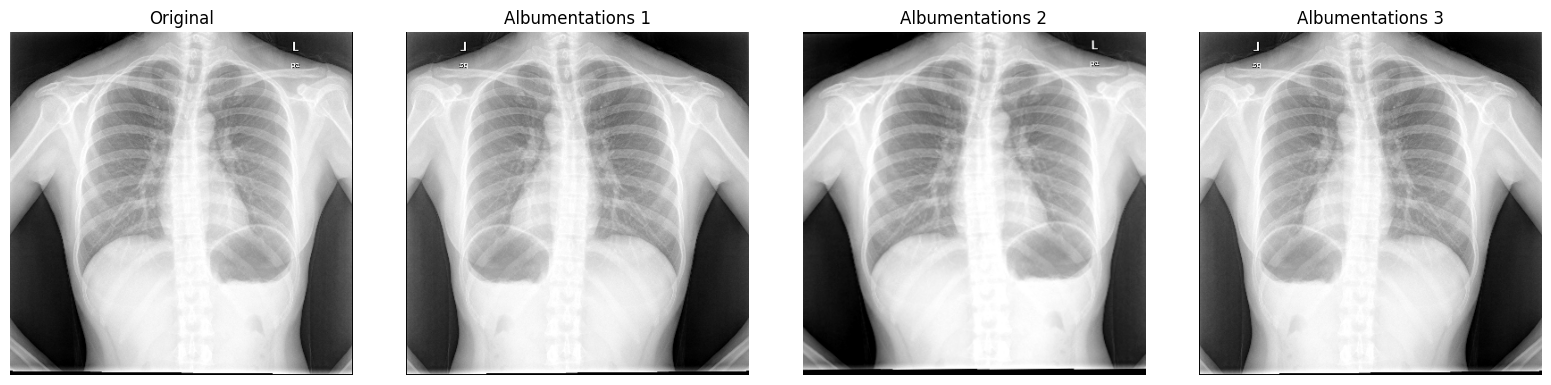

In [37]:
preview_id = images_df.sample(1, random_state=SEED).iloc[0].ImageId
preview_image, preview_label = image_and_label(preview_id)
preview_image = normalize_percentile(preview_image).astype(np.float32)

base = valid_transform(image=preview_image)["image"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for col in range(4):
    if col == 0:
        image_aug = base
        title = "Original"
    else:
        image_aug = train_transform(image=preview_image)["image"]
        title = f"Albumentations {col}"
    axes[col].imshow(image_aug, cmap="gray", vmin=0, vmax=1)
    axes[col].set_title(title)
    axes[col].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.94])


## 5. ResNet-34 Binary Classifier

This section defines a ResNet-34 model for binary classification. ResNet-34 is a convolutional neural network that uses residual connections, which help information flow through deeper networks during training.

The original ResNet-34 classifier is replaced with a small output layer that produces one score, called a logit. Higher logits mean the model is more confident the image shows tuberculosis.



In [38]:
class TBClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = resnet34(weights=None)
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.model(x)


model = TBClassifier().to(DEVICE)
with torch.no_grad():
    test_logits = model(images[:2].to(DEVICE))

print(f"Test output shape: {test_logits.shape} = batch size, one TB logit per image")


Test output shape: torch.Size([2, 1]) = batch size, one TB logit per image


## 6. Train

Training repeatedly shows image batches to the model, measures prediction error, and updates the model weights. The notebook tracks common classification metrics so we can see whether performance improves on both the training and validation splits.



In [39]:
def binary_auc(probs: np.ndarray, targets: np.ndarray) -> float:
    probs = np.asarray(probs, dtype=np.float32).reshape(-1)
    targets = np.asarray(targets, dtype=np.int64).reshape(-1)
    pos = probs[targets == 1]
    neg = probs[targets == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    comparisons = pos[:, None] - neg[None, :]
    return float((comparisons > 0).mean() + 0.5 * (comparisons == 0).mean())


def classification_metrics_from_probs(probs: np.ndarray, targets: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    probs = np.asarray(probs, dtype=np.float32).reshape(-1)
    labels = np.asarray(targets, dtype=np.int64).reshape(-1)
    preds = (probs >= threshold).astype(np.int64)

    tp = int(((preds == 1) & (labels == 1)).sum())
    tn = int(((preds == 0) & (labels == 0)).sum())
    fp = int(((preds == 1) & (labels == 0)).sum())
    fn = int(((preds == 0) & (labels == 1)).sum())

    accuracy = (tp + tn) / max(1, tp + tn + fp + fn)
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    f1 = 2 * precision * recall / max(1e-7, precision + recall)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": binary_auc(probs, labels),
    }


def classification_metrics_from_logits(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5) -> dict[str, float]:
    probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
    labels = targets.detach().cpu().numpy().reshape(-1).astype(np.int64)
    return classification_metrics_from_probs(probs, labels, threshold=threshold)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_images = 0
    all_logits = []
    all_targets = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels, _ in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_images += batch_size
            all_logits.append(logits.detach().cpu())
            all_targets.append(labels.detach().cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    metrics = classification_metrics_from_logits(all_logits, all_targets)
    metrics["loss"] = total_loss / max(1, total_images)
    return metrics


The next cell is the actual training loop. It sets the number of epochs, learning-rate schedule, checkpoint path, and class-balanced binary cross-entropy loss. Each epoch trains on the Shenzhen training split, evaluates on the validation split, records loss and classification metrics, saves the best checkpoint by validation AUC, advances the scheduler, and prints a compact progress summary.


In [40]:
EPOCHS = 10
LEARNING_RATE = 1e-3
MIN_LEARNING_RATE = 1e-5
CHECKPOINT_PATH = RESULTS_DIR / "resnet34_shenzhen_tb_classifier.pt"

train_labels = label_lookup.loc[train_ids_run].to_numpy()
positive_count = int(train_labels.sum())
negative_count = int(len(train_labels) - positive_count)
pos_weight = torch.tensor([negative_count / max(1, positive_count)], device=DEVICE, dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=MIN_LEARNING_RATE)
history = []
best_valid_auc = -float("inf")
best_valid_loss = float("inf")
best_model_state = None

print(f"Training labels: {positive_count} TB and {negative_count} No TB images. Positive class weight: {pos_weight.item():.3f}")

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer)
    valid_metrics = run_epoch(model, valid_loader, criterion)
    current_lr = optimizer.param_groups[0]["lr"]
    history.append({"epoch": epoch, "lr": current_lr, **{f"train_{k}": v for k, v in train_metrics.items()}, **{f"valid_{k}": v for k, v in valid_metrics.items()}})

    valid_auc = valid_metrics["auc"]
    is_better = valid_auc > best_valid_auc or (np.isnan(valid_auc) and valid_metrics["loss"] < best_valid_loss)
    if is_better:
        best_valid_auc = valid_auc
        best_valid_loss = valid_metrics["loss"]
        best_model_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history": history,
            "image_size": IMAGE_SIZE,
            "pos_weight": pos_weight.detach().cpu(),
            "image_mean": TRAIN_IMAGE_MEAN,
            "image_std": TRAIN_IMAGE_STD,
            "normalization_stats_source": "Shenzhen train split",
            "train_dataset": "Shenzhen",
            "external_validation_dataset": "Montgomery",
        }, CHECKPOINT_PATH)

    scheduler.step()
    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"lr={current_lr:.2e} "
        f"train_loss={train_metrics['loss']:.4f} train_f1={train_metrics['f1']:.4f} train_auc={train_metrics['auc']:.4f} "
        f"valid_loss={valid_metrics['loss']:.4f} valid_f1={valid_metrics['f1']:.4f} valid_auc={valid_metrics['auc']:.4f}"
    )

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Best model checkpoint saved to: {CHECKPOINT_PATH}")


Training labels: 269 TB and 261 No TB images. Positive class weight: 0.970


Epoch 01/10 lr=1.00e-03 train_loss=0.7023 train_f1=0.6953 train_auc=0.7090 valid_loss=1.5266 valid_f1=0.6709 valid_auc=0.7540


Epoch 02/10 lr=9.76e-04 train_loss=0.5516 train_f1=0.7266 train_auc=0.7886 valid_loss=0.5487 valid_f1=0.7480 valid_auc=0.7679


Epoch 03/10 lr=9.05e-04 train_loss=0.5028 train_f1=0.7674 train_auc=0.8183 valid_loss=0.5330 valid_f1=0.7258 valid_auc=0.7885


Epoch 04/10 lr=7.96e-04 train_loss=0.5519 train_f1=0.7088 train_auc=0.7712 valid_loss=0.6153 valid_f1=0.5600 valid_auc=0.7644


...

Epoch 06/10 lr=5.05e-04 train_loss=0.5117 train_f1=0.7524 train_auc=0.8158 valid_loss=1.1599 valid_f1=0.0294 valid_auc=0.7185


Epoch 07/10 lr=3.52e-04 train_loss=0.4955 train_f1=0.7614 train_auc=0.8287 valid_loss=0.5458 valid_f1=0.7227 valid_auc=0.7846


Epoch 08/10 lr=2.14e-04 train_loss=0.4885 train_f1=0.7857 train_auc=0.8180 valid_loss=0.5125 valid_f1=0.7350 valid_auc=0.7995


Epoch 09/10 lr=1.05e-04 train_loss=0.4826 train_f1=0.7557 train_auc=0.8387 valid_loss=0.5063 valid_f1=0.7368 valid_auc=0.8241


Epoch 10/10 lr=3.42e-05 train_loss=0.4498 train_f1=0.7944 train_auc=0.8504 valid_loss=0.4975 valid_f1=0.7304 valid_auc=0.8195
Best model checkpoint saved to: results/resnet34_shenzhen_tb_classifier.pt


## 7. Internal And External Validation

After training, the best model is evaluated on two held-out groups:

- **Internal validation:** Shenzhen images that were not used to update model weights, but still come from the same source as the training data.
- **External validation:** Montgomery images, kept separate until the end and collected from a different source.

The internal split helps check whether training is stable and whether the model can handle held-out images from the same data distribution. External validation is a stricter test: it asks whether the model still works when the image source changes.

Comparing both validation results helps separate **robust clinical signal** from **dataset-specific behavior**. This matters because a medical imaging model should generalize across sites, equipment, and patient groups, not only perform well on images that resemble its training source.



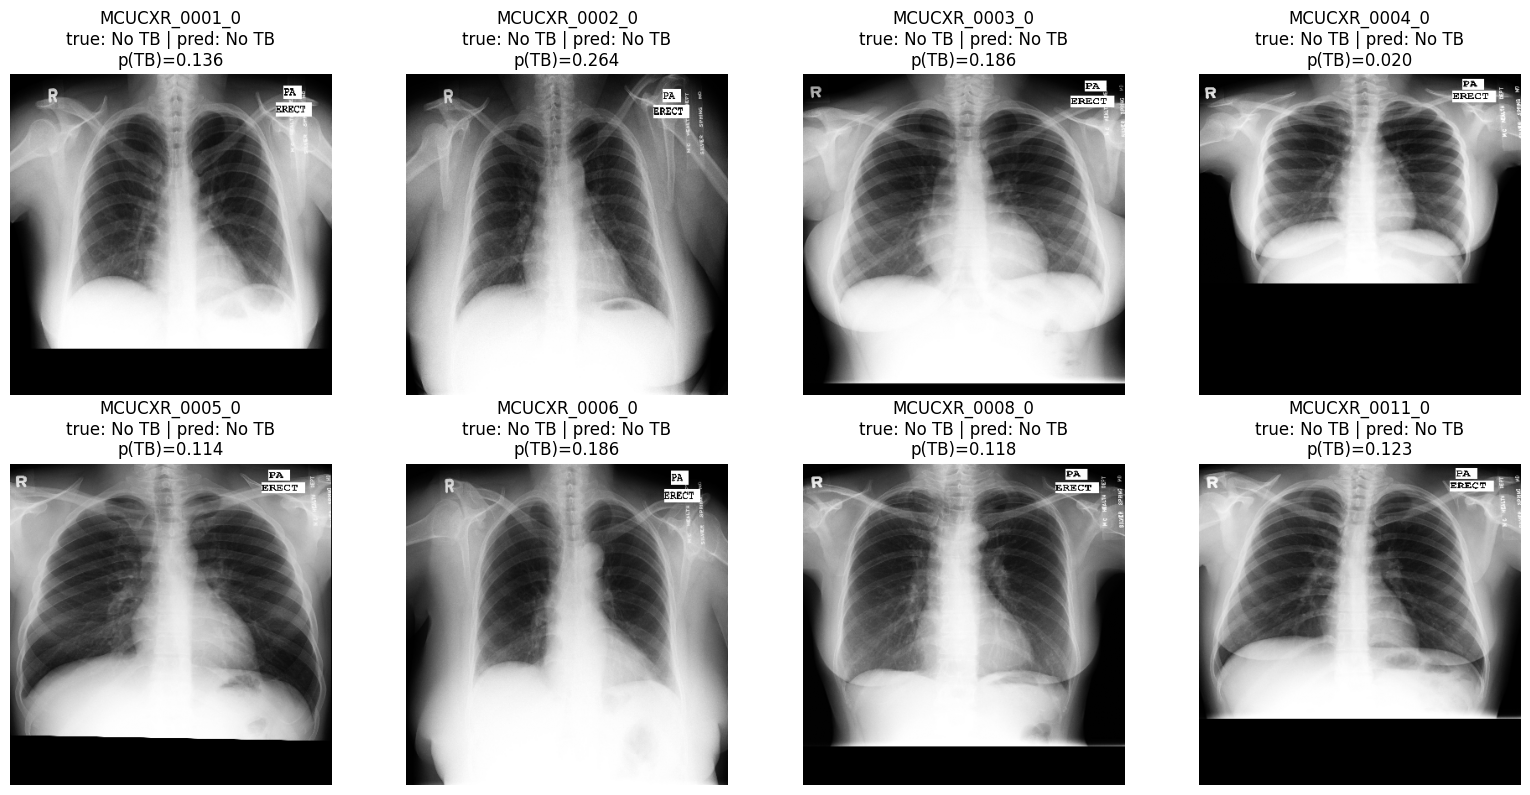

In [41]:
@torch.no_grad()
def predict_batch(model, images: torch.Tensor, threshold: float = 0.5) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    probs = torch.sigmoid(model(images.to(DEVICE))).cpu().numpy().reshape(-1)
    preds = (probs >= threshold).astype(np.int64)
    return preds, probs


preview_external_ids = external_ids[:max(BATCH_SIZE, 4)]
preview_external_ds = TBClassificationDataset(
    preview_external_ids,
    external_images_df,
    transform=valid_transform,
    image_mean=TRAIN_IMAGE_MEAN,
    image_std=TRAIN_IMAGE_STD,
)
preview_external_loader = DataLoader(
    preview_external_ds,
    batch_size=min(BATCH_SIZE, len(preview_external_ds)),
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

images, labels, image_ids = next(iter(preview_external_loader))
pred_labels, pred_probs = predict_batch(model, images)
true_labels = labels.numpy().reshape(-1).astype(np.int64)

n = min(8, images.shape[0])
cols = min(4, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for i in range(n):
    image = images[i].numpy().transpose(1, 2, 0)
    image = image * TRAIN_IMAGE_STD + TRAIN_IMAGE_MEAN
    image = np.clip(image[..., 0], 0, 1)
    true_name = "TB" if true_labels[i] == 1 else "No TB"
    pred_name = "TB" if pred_labels[i] == 1 else "No TB"
    axes[i].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[i].set_title(f"{image_ids[i]}\ntrue: {true_name} | pred: {pred_name}\np(TB)={pred_probs[i]:.3f}")
    axes[i].axis("off")

for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()

## 8. Teaching Point

The model performs much better on the **Shenzhen internal validation split** than on the **Montgomery external validation set**. This happens even though both datasets are processed in the same way: images are resized, converted into the same tensor format, and normalized with the Shenzhen training mean and standard deviation.

### Same preprocessing does not mean same data distribution.

Normalization helps align low-level pixel statistics, but it cannot erase the deeper differences between datasets. Chest X-rays can vary because of:

- Scanner characteristics or acquisition protocol;
- Image resolution, contrast, or preprocessing artifacts;
- Patient population or disease prevalence;
- Label conventions or annotation quality.

These differences create **data shift**. The model may have learned useful TB-related signal within the Shenzhen source, but the Montgomery results show that this signal does not transfer cleanly. The fixed `0.5` threshold may also be poorly calibrated once the data source changes.

That changes the interpretation of the experiment. The internal validation score tells us the model learned something. The external validation score tells us whether that learning is robust enough to survive outside its original dataset.

**Takeaway:** external validation is not just a final metric. It is a stress test for real-world use. In medical imaging, a model should not only perform well on familiar images; it should remain reliable when the hospital, scanner, protocol, and patient population change.

,split,accuracy,precision,recall,f1,auc
0,shenzhen_valid,0.772727,0.893617,0.626866,0.736842,0.824110
1,montgomery_external,0.579710,0.000000,0.000000,0.000000,0.566595


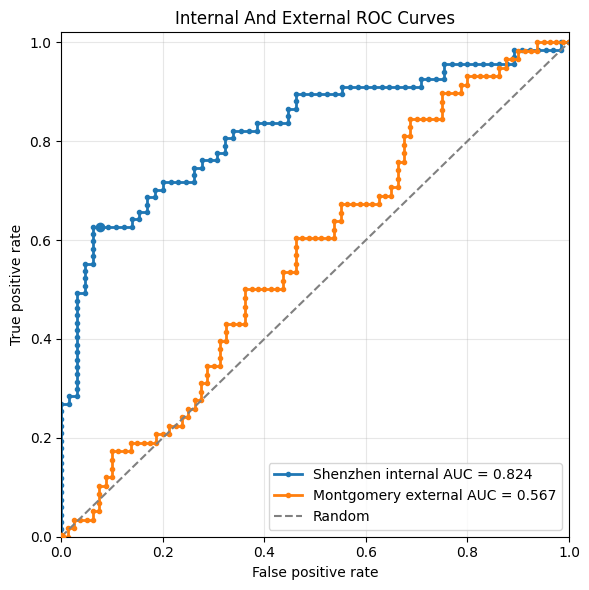

In [ ]:
@torch.no_grad()
def collect_validation_predictions(model, loader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_probs = []
    all_targets = []
    for images, labels, _ in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
        targets = labels.numpy().reshape(-1).astype(np.int64)
        all_probs.append(probs)
        all_targets.append(targets)
    return np.concatenate(all_probs), np.concatenate(all_targets)


def roc_curve_points(probs: np.ndarray, targets: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    probs = np.asarray(probs, dtype=np.float32).reshape(-1)
    targets = np.asarray(targets, dtype=np.int64).reshape(-1)
    thresholds = np.r_[np.inf, np.sort(np.unique(probs))[::-1], -np.inf]
    positives = max(1, int((targets == 1).sum()))
    negatives = max(1, int((targets == 0).sum()))

    tpr = []
    fpr = []
    for threshold in thresholds:
        preds = probs >= threshold
        tp = int(((preds == 1) & (targets == 1)).sum())
        fp = int(((preds == 1) & (targets == 0)).sum())
        tpr.append(tp / positives)
        fpr.append(fp / negatives)
    return np.asarray(fpr), np.asarray(tpr), thresholds


def roc_point_at_threshold(probs: np.ndarray, targets: np.ndarray, threshold: float = 0.5) -> tuple[float, float]:
    preds = probs >= threshold
    positives = max(1, int((targets == 1).sum()))
    negatives = max(1, int((targets == 0).sum()))
    tp = int(((preds == 1) & (targets == 1)).sum())
    fp = int(((preds == 1) & (targets == 0)).sum())
    return fp / negatives, tp / positives


valid_probs, valid_targets = collect_validation_predictions(model, valid_loader)
external_probs, external_targets = collect_validation_predictions(model, external_valid_loader)


fig, ax = plt.subplots(figsize=(6, 6))
for split_name, probs, targets in [
    ("Shenzhen internal", valid_probs, valid_targets),
    ("Montgomery external", external_probs, external_targets),
]:
    auc = binary_auc(probs, targets)
    fpr, tpr, _ = roc_curve_points(probs, targets)
    threshold_fpr, threshold_tpr = roc_point_at_threshold(probs, targets, threshold=0.5)
    ax.plot(fpr, tpr, marker=".", linewidth=2, label=f"{split_name} AUC = {auc:.3f}")
    ax.scatter([threshold_fpr], [threshold_tpr], zorder=3)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Internal And External ROC Curves")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
